In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv("Nassau Candy Distributor.csv")

In [26]:
df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [7]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [9]:
df = df[df['Sales'] > 0]
df = df[df['Gross Profit'] > 0]

In [10]:
df['Units'] = df['Units'].fillna(df['Units'].median())

In [11]:
df['Division'] = df['Division'].str.strip()
df['Product Name'] = df['Product Name'].str.strip()

In [12]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

In [13]:
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

In [14]:
total_sales = df['Sales'].sum()

df['Revenue Contribution %'] = (df['Sales'] / total_sales) * 100

In [15]:
total_profit = df['Gross Profit'].sum()

df['Profit Contribution %'] = (df['Gross Profit'] / total_profit) * 100

In [16]:
top_profit = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

top_profit.head(10)

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64

In [17]:
top_margin = df.groupby('Product Name')['Gross Margin %'].mean().sort_values(ascending=False)

top_margin.head(10)

Product Name
Everlasting Gobstopper               80.000000
Hair Toffee                          77.777778
Wonka Bar - Nutty Crunch Surprise    71.346705
Wonka Bar -Scrumdiddlyumptious       69.444444
Wonka Bar - Fudge Mallows            66.666667
Wonka Bar - Triple Dazzle Caramel    65.333333
Wonka Bar - Milk Chocolate           64.923077
Laffy Taffy                          62.311558
Fizzy Lifting Drinks                 60.000000
Wonka Gum                            52.000000
Name: Gross Margin %, dtype: float64

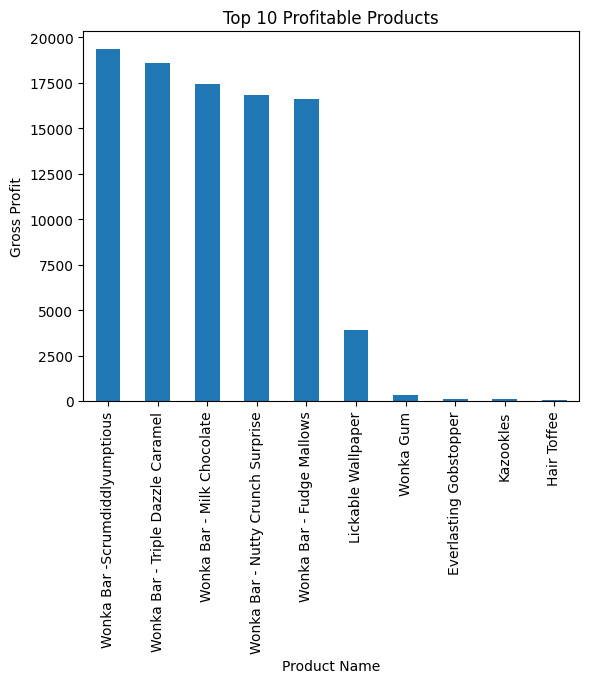

In [18]:
top_profit.head(10).plot(kind='bar')

plt.title("Top 10 Profitable Products")
plt.ylabel("Gross Profit")
plt.show()

In [19]:
division_perf = df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross Margin %':'mean'
}).reset_index()

division_perf

,Division,Sales,Gross Profit,Gross Margin %
0,Chocolate,131692.90,88824.62,67.458162
1,Other,9663.25,4333.45,37.672457
2,Sugar,427.48,284.73,57.689001


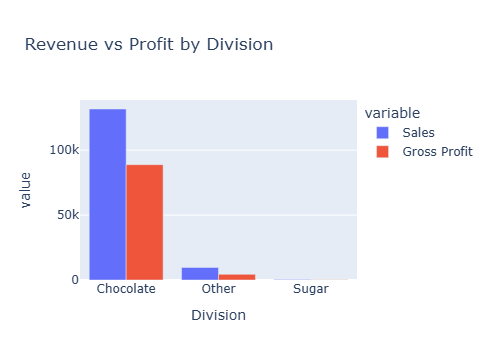

In [20]:
fig = px.bar(
    division_perf,
    x='Division',
    y=['Sales','Gross Profit'],
    barmode='group',
    title='Revenue vs Profit by Division'
)

fig.show()

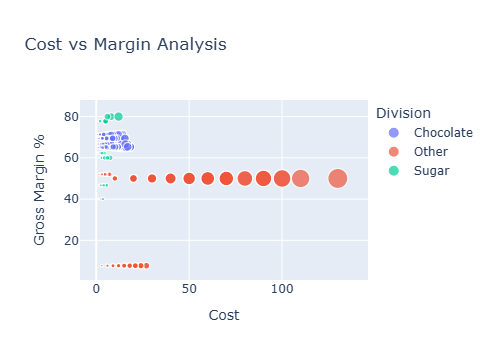

In [21]:
fig = px.scatter(
    df,
    x='Cost',
    y='Gross Margin %',
    color='Division',
    size='Sales',
    hover_data=['Product Name'],
    title='Cost vs Margin Analysis'
)

fig.show()

In [22]:
risk_products = df[df['Gross Margin %'] < 10]

risk_products[['Product Name','Sales','Gross Margin %']]

,Product Name,Sales,Gross Margin %
26,Kazookles,9.75,7.692308
92,Kazookles,13.00,7.692308
160,Kazookles,19.50,7.692308
200,Kazookles,9.75,7.692308
210,Kazookles,13.00,7.692308
...,...,...,...
9259,Kazookles,9.75,7.692308
9357,Kazookles,13.00,7.692308
9699,Kazookles,9.75,7.692308
9859,Kazookles,3.25,7.692308


In [23]:
pareto = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

pareto_df = pareto.reset_index()

pareto_df['Cumulative Profit %'] = pareto_df['Gross Profit'].cumsum() / pareto_df['Gross Profit'].sum() * 100

pareto_df.head()

,Product Name,Gross Profit,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717
4,Wonka Bar - Fudge Mallows,16593.60,95.057747


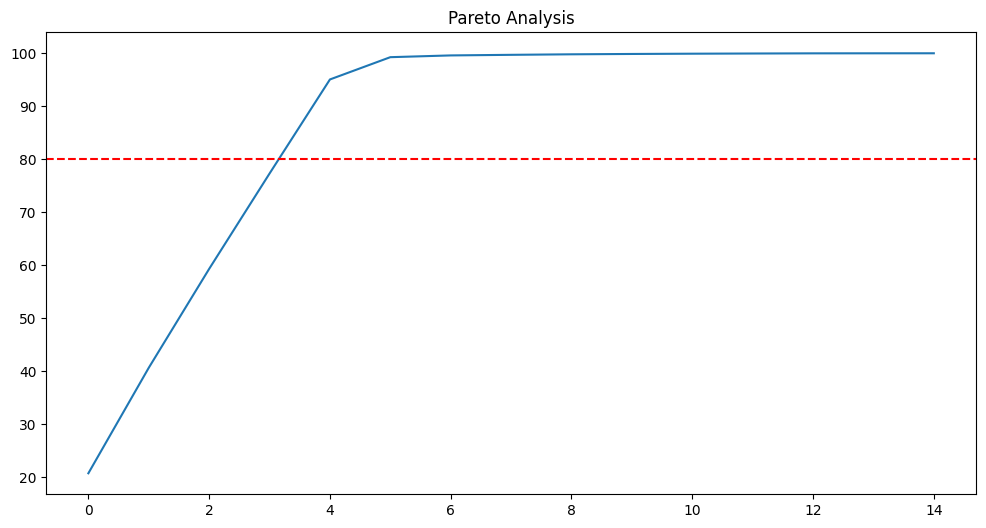

In [24]:
plt.figure(figsize=(12,6))

plt.plot(pareto_df['Cumulative Profit %'])

plt.axhline(80, color='red', linestyle='--')

plt.title("Pareto Analysis")

plt.show()